# UK Education Attainment Gap Analysis

## Does ethnicity, gender, or deprivation predict your A-Level results in England?

This analysis uses **official UK Government data** (Department for Education, 2020-2025) to examine:

1. **The ethnicity attainment gap** — which ethnic groups consistently outperform or underperform?
2. **The deprivation effect** — does being disadvantaged affect all ethnic groups equally?
3. **Gender × ethnicity interaction** — are gaps widening or narrowing for men vs women?
4. **The immigration angle** — how do students from immigrant backgrounds (Indian, Pakistani, Bangladeshi, Black African) compare to White British students?
5. **10-year policy impact** — has the gap improved since the government's widening participation push?

**Personal context:** I'm a PSW graduate visa holder in the UK. I came here for an MSc, contributed to the economy, and now face deportation because of visa policy — not capability. This analysis asks whether the education system that attracted me here is actually equitable.

---

**Data sources:**
- [DfE A-Level attainment by ethnicity, disadvantage, sex (2020-2025)](https://explore-education-statistics.service.gov.uk/data-catalogue/data-set/53c46fc6-d94b-49b2-8b97-68322e7547bd)
- [DfE Level 2/3 attainment ages 16-25 by ethnicity (2007-2024)](https://explore-education-statistics.service.gov.uk/data-catalogue/data-set/282295e1-a76d-4854-8256-7b14eda3b708)
- [DfE Disadvantage gap index (KS2)](https://explore-education-statistics.service.gov.uk/data-catalogue/data-set/e1a9549e-346d-4b49-b343-af943f35dd97)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

print('Libraries loaded.')

Libraries loaded.


## 1. Load and Clean Data

In [2]:
# A-Level attainment data (2020-2025)
alevel = pd.read_csv('../data/raw/alevel_ethnicity.csv')

# Convert time period to readable year
alevel['year'] = alevel['time_period'].astype(str).str[:4].astype(int)
alevel['year_label'] = alevel['time_period'].astype(str).apply(lambda x: f"20{x[2:4]}/{'20' if int(x[4:]) < 50 else '19'}{x[4:]}" if len(x) == 6 else x)

print(f'A-Level dataset: {len(alevel):,} rows, {len(alevel.columns)} columns')
print(f'Years: {sorted(alevel.time_period.unique())}')
print(f'Ethnic groups: {alevel.ethnicity_minor.nunique()}')
print(f'\nSample:')
alevel.head(3)

A-Level dataset: 7,200 rows, 45 columns
Years: [np.int64(202021), np.int64(202122), np.int64(202223), np.int64(202324), np.int64(202425)]
Ethnic groups: 24

Sample:


,time_period,time_identifier,geographic_level,country_code,country_name,version,sex,disadvantage,ethnicity_minor,sen,...,pc_level3_vocational_students_entered_tech_levels,entered_any_level3_vocational_excluding_tech_levels,pc_level3_vocational_students_entered_applied_generals,number_of_students_highest_entry_was_l2,pc_level2_vocational_students_entered_technicalcertificate,number_of_students_technicalcertificate,aps_per_entry_technicalcertificate,aps_per_entry_grade_technicalcertificate,year,year_label
0,202425,Academic year,National,E92000001,England,Provisional,All,All,All,All,...,25.972,199955,67.216,75991,10.101,8901,5.6034,L2Merit-,2024,2024/2025
1,202324,Academic year,National,E92000001,England,Revised,All,All,All,All,...,29.341,191521,68.025,67984,10.63,8487,5.6294,L2Merit-,2023,2023/2024
2,202223,Academic year,National,E92000001,England,Revised,All,All,All,All,...,31.961,178698,68.662,39201,9.145,3844,5.6763,L2Merit-,2022,2022/2023


In [3]:
# Level 2/3 characteristics data (longer time series)
chars = pd.read_csv('../data/raw/level23_characteristics.csv')
chars['year'] = chars['time_period'].astype(str).str[:4].astype(int)

print(f'Level 2/3 characteristics: {len(chars):,} rows')
print(f'Years: {sorted(chars.time_period.unique())}')
print(f'Characteristic groups: {chars.characteristic_group.unique()}')

Level 2/3 characteristics: 53,696 rows
Years: [np.int64(200405), np.int64(200506), np.int64(200607), np.int64(200708), np.int64(200809), np.int64(200910), np.int64(201011), np.int64(201112), np.int64(201213), np.int64(201314), np.int64(201415), np.int64(201516), np.int64(201617), np.int64(201718), np.int64(201819), np.int64(201920), np.int64(202021), np.int64(202122), np.int64(202223), np.int64(202324), np.int64(202425)]
Characteristic groups: ['FSM (Free School Meal) status' 'Gender'
 'IDACI (Income Deprivation Affecting Children Index)' 'Total'
 'SEN (Special Educational Need)'
 'SEN (Special Educational Need) Provision'
 'Ethnicity Minor and FSM (Free School Meal) status' 'Ethnicity Major'
 'Ethnicity Minor' 'Ethnicity Major and FSM (Free School Meal) status'
 'Ethnicity Major and FSM (Free School Meal) status and gender'
 'Primary SEN (Special Educational Need)' 'Disadvantaged status']


## 2. The Ethnicity Attainment Gap — A-Level Results

In [4]:
# Filter: All sexes, All disadvantage status, major ethnic groups only
major_groups = ['White', 'Asian or Asian British', 'Black or Black British', 
                'Mixed Dual background', 'Any other ethnic group']

filtered = alevel[
    (alevel['sex'] == 'All') &
    (alevel['disadvantage'] == 'All') &
    (alevel['ethnicity_minor'].isin(major_groups)) &
    (alevel['sen'] == 'All')
].copy()

# Convert APS to numeric
for col in ['aps_a_level', 'aps_a_level_equivalent']:
    if col in filtered.columns:
        filtered[col] = pd.to_numeric(filtered[col], errors='coerce')

# Find the best available score column
score_cols = [c for c in filtered.columns if 'aps' in c.lower() or 'grade' in c.lower() or 'point' in c.lower()]
print(f'Available score columns: {score_cols}')
print(f'Numeric columns: {filtered.select_dtypes(include=[np.number]).columns.tolist()}')
filtered.head()

Available score columns: ['aps_per_entry_alev', 'aps_per_entry_grade_alev', 'aps_per_entry_acad', 'aps_per_entry_grade_acad', 'aps_per_entry_agen', 'aps_per_entry_grade_agen', 'aps_per_entry_tlev', 'aps_per_entry_grade_tlev', 'aps_per_entry_best3', 'aps_per_entry_grade_best3', 'aps_per_entry_technicalcertificate', 'aps_per_entry_grade_technicalcertificate']
Numeric columns: ['time_period', 'year']


,time_period,time_identifier,geographic_level,country_code,country_name,version,sex,disadvantage,ethnicity_minor,sen,...,pc_level3_vocational_students_entered_tech_levels,entered_any_level3_vocational_excluding_tech_levels,pc_level3_vocational_students_entered_applied_generals,number_of_students_highest_entry_was_l2,pc_level2_vocational_students_entered_technicalcertificate,number_of_students_technicalcertificate,aps_per_entry_technicalcertificate,aps_per_entry_grade_technicalcertificate,year,year_label
60,202425,Academic year,National,E92000001,England,Provisional,All,All,Any other ethnic group,All,...,30.946,3933,81.414,1100,6,80,5.1498,L2Pass,2024,2024/2025
61,202324,Academic year,National,E92000001,England,Revised,All,All,Any other ethnic group,All,...,34.725,3707,81.252,1027,5.161,72,5.2605,L2Pass+,2023,2023/2024
62,202223,Academic year,National,E92000001,England,Revised,All,All,Any other ethnic group,All,...,35.874,3492,81.701,579,3.972,23,5.1782,L2Pass+,2022,2022/2023
63,202122,Academic year,National,E92000001,England,Revised,All,All,Any other ethnic group,All,...,39.461,3294,81.603,234,5.556,13,6.3061,L2Merit+,2021,2021/2022
64,202021,Academic year,National,E92000001,England,Final,All,All,Any other ethnic group,All,...,16.904,2759,58.536,426,6.338,42,5.1033,L2Pass,2020,2020/2021


In [5]:
# Attainment by ethnicity over time
# Use number_of_students_level3 as proxy for attainment rate
numeric_cols = filtered.select_dtypes(include=[np.number]).columns
print('Numeric columns available for analysis:')
for col in numeric_cols:
    if filtered[col].notna().sum() > 0:
        print(f'  {col}: min={filtered[col].min()}, max={filtered[col].max()}, non-null={filtered[col].notna().sum()}')

Numeric columns available for analysis:
  time_period: min=202021, max=202425, non-null=25
  year: min=2020, max=2024, non-null=25


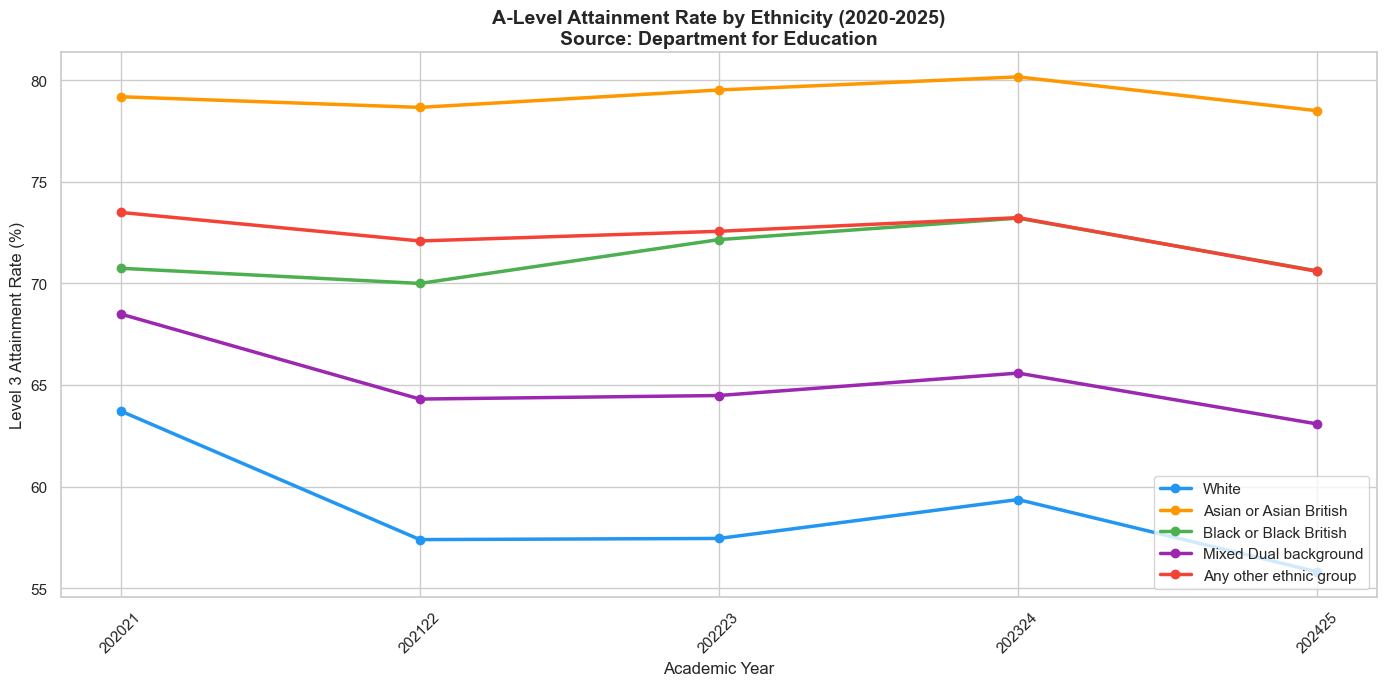

In [6]:
# Plot: A-Level attainment rate by ethnicity over time
# Calculate percentage achieving Level 3 from total potential students
filtered['attainment_rate'] = pd.to_numeric(filtered.get('number_of_students_level3', 0), errors='coerce') / \
                               pd.to_numeric(filtered.get('number_of_students_potential', 1), errors='coerce') * 100

trend = filtered.groupby(['time_period', 'ethnicity_minor'])['attainment_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
colors = {'White': '#2196F3', 'Asian or Asian British': '#FF9800', 
          'Black or Black British': '#4CAF50', 'Mixed Dual background': '#9C27B0',
          'Any other ethnic group': '#F44336'}

for ethnicity in major_groups:
    data = trend[trend['ethnicity_minor'] == ethnicity]
    if not data.empty:
        ax.plot(data['time_period'].astype(str), data['attainment_rate'], 
                marker='o', linewidth=2.5, label=ethnicity, color=colors.get(ethnicity, 'grey'))

ax.set_xlabel('Academic Year')
ax.set_ylabel('Level 3 Attainment Rate (%)')
ax.set_title('A-Level Attainment Rate by Ethnicity (2020-2025)\nSource: Department for Education', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../charts/01_ethnicity_attainment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. The Deprivation × Ethnicity Intersection

Does being disadvantaged hit all ethnic groups equally? Or are some groups doubly penalised?

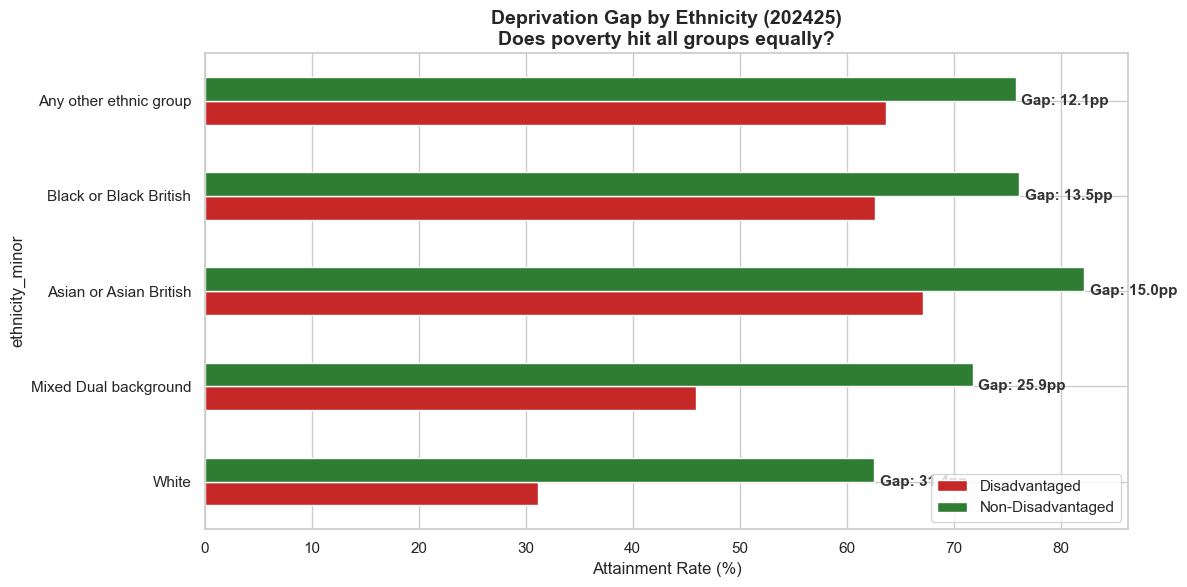

In [7]:
# Filter for latest year, both disadvantage statuses
latest_year = alevel['time_period'].max()
dep = alevel[
    (alevel['time_period'] == latest_year) &
    (alevel['sex'] == 'All') &
    (alevel['sen'] == 'All') &
    (alevel['disadvantage'].isin(['Disadvantaged', 'Non-Disadvantaged'])) &
    (alevel['ethnicity_minor'].isin(major_groups))
].copy()

dep['attainment_rate'] = pd.to_numeric(dep.get('number_of_students_level3', 0), errors='coerce') / \
                          pd.to_numeric(dep.get('number_of_students_potential', 1), errors='coerce') * 100

pivot = dep.pivot_table(index='ethnicity_minor', columns='disadvantage', values='attainment_rate', aggfunc='mean')
if not pivot.empty:
    pivot['gap'] = pivot.get('Non-Disadvantaged', 0) - pivot.get('Disadvantaged', 0)
    pivot = pivot.sort_values('gap', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    pivot[['Disadvantaged', 'Non-Disadvantaged']].plot(kind='barh', ax=ax, 
                                                        color=['#C62828', '#2E7D32'])
    ax.set_xlabel('Attainment Rate (%)')
    ax.set_title(f'Deprivation Gap by Ethnicity ({latest_year})\nDoes poverty hit all groups equally?', 
                 fontsize=14, fontweight='bold')
    ax.legend(['Disadvantaged', 'Non-Disadvantaged'])
    
    for i, (idx, row) in enumerate(pivot.iterrows()):
        gap = row.get('gap', 0)
        if pd.notna(gap):
            ax.text(max(row.get('Non-Disadvantaged', 0), row.get('Disadvantaged', 0)) + 0.5, 
                    i, f'Gap: {gap:.1f}pp', va='center', fontweight='bold', color='#333')
    
    plt.tight_layout()
    plt.savefig('../charts/02_deprivation_ethnicity_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No data available for this combination. Checking alternative columns...')
    print(dep[['ethnicity_minor', 'disadvantage']].value_counts())

## 4. Gender × Ethnicity Interaction

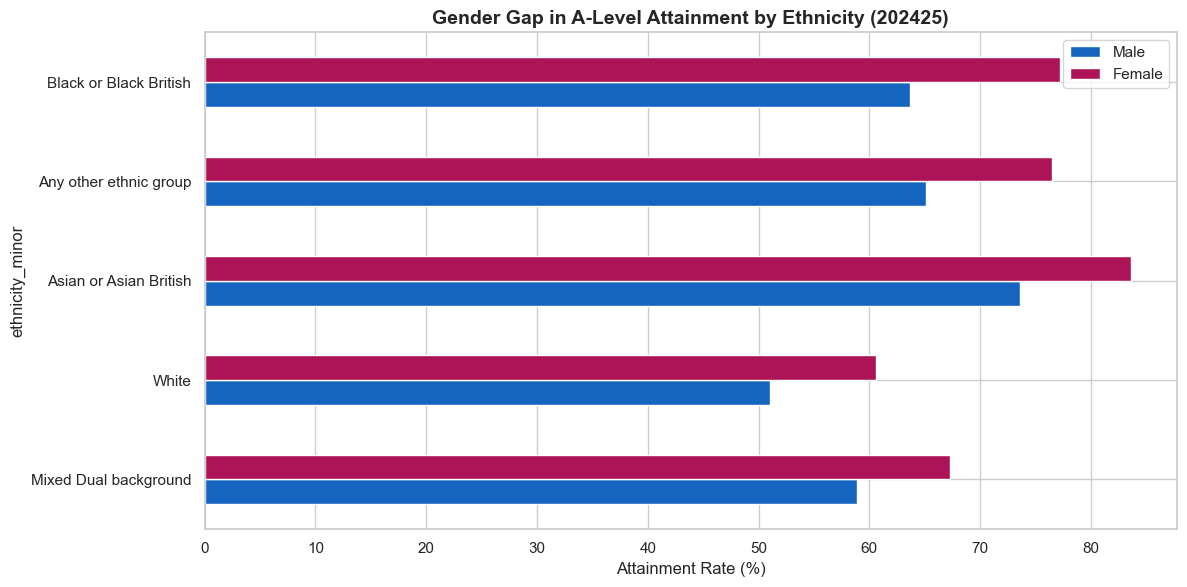


Gender gap (Female - Male) in percentage points:
ethnicity_minor
Mixed Dual background      8.411520
White                      9.592625
Asian or Asian British     9.955123
Any other ethnic group    11.359011
Black or Black British    13.598054


In [8]:
# Gender gap by ethnicity
gender = alevel[
    (alevel['time_period'] == latest_year) &
    (alevel['sex'].isin(['Male', 'Female'])) &
    (alevel['disadvantage'] == 'All') &
    (alevel['sen'] == 'All') &
    (alevel['ethnicity_minor'].isin(major_groups))
].copy()

gender['attainment_rate'] = pd.to_numeric(gender.get('number_of_students_level3', 0), errors='coerce') / \
                             pd.to_numeric(gender.get('number_of_students_potential', 1), errors='coerce') * 100

gender_pivot = gender.pivot_table(index='ethnicity_minor', columns='sex', values='attainment_rate', aggfunc='mean')
if not gender_pivot.empty:
    gender_pivot['gender_gap'] = gender_pivot.get('Female', 0) - gender_pivot.get('Male', 0)
    gender_pivot = gender_pivot.sort_values('gender_gap', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    gender_pivot[['Male', 'Female']].plot(kind='barh', ax=ax, color=['#1565C0', '#AD1457'])
    ax.set_xlabel('Attainment Rate (%)')
    ax.set_title(f'Gender Gap in A-Level Attainment by Ethnicity ({latest_year})', fontsize=14, fontweight='bold')
    ax.legend(['Male', 'Female'])
    plt.tight_layout()
    plt.savefig('../charts/03_gender_ethnicity_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('\nGender gap (Female - Male) in percentage points:')
    print(gender_pivot['gender_gap'].to_string())

## 5. The Immigration Angle

How do students from historically immigrant backgrounds compare? Indian, Pakistani, Bangladeshi, Black African — these are communities with strong ties to immigration. How do their children perform in the UK education system?

Available groups: ['Asian or Asian British - Indian', 'Asian or Asian British - Pakistani', 'Asian or Asian British - Bangladeshi', 'Asian or Asian British - Chinese', 'Black or Black British - Black African', 'Black or Black British - Black Caribbean', 'White', 'White - White British']


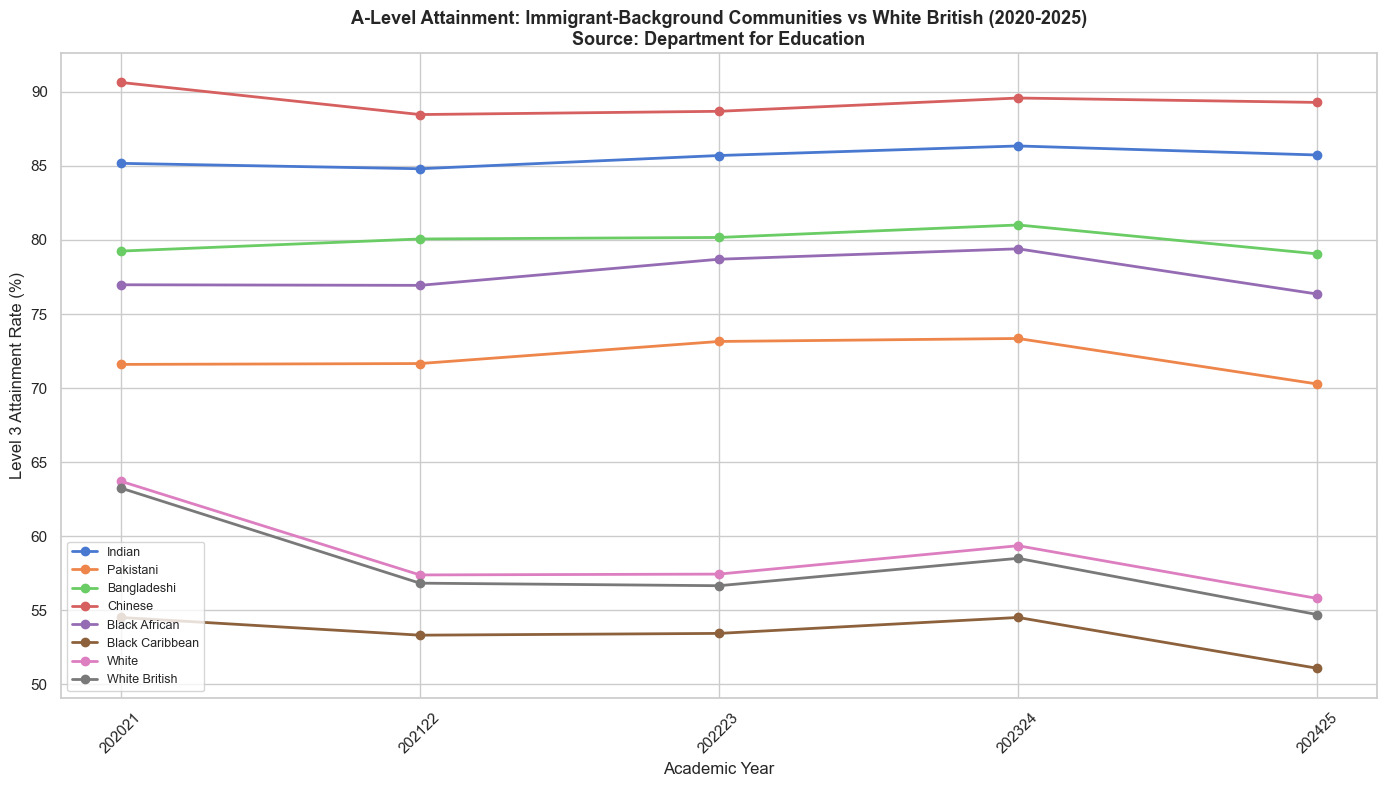

In [9]:
# Detailed ethnic breakdown
immigrant_groups = [
    'Asian or Asian British - Indian',
    'Asian or Asian British - Pakistani', 
    'Asian or Asian British - Bangladeshi',
    'Asian or Asian British - Chinese',
    'Black or Black British - Black African',
    'Black or Black British - Black Caribbean',
    'White',
    'White - White British'
]

available = [g for g in immigrant_groups if g in alevel['ethnicity_minor'].unique()]
print(f'Available groups: {available}')

imm = alevel[
    (alevel['sex'] == 'All') &
    (alevel['disadvantage'] == 'All') &
    (alevel['sen'] == 'All') &
    (alevel['ethnicity_minor'].isin(available))
].copy()

imm['attainment_rate'] = pd.to_numeric(imm.get('number_of_students_level3', 0), errors='coerce') / \
                          pd.to_numeric(imm.get('number_of_students_potential', 1), errors='coerce') * 100

imm_trend = imm.groupby(['time_period', 'ethnicity_minor'])['attainment_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 8))
for group in available:
    data = imm_trend[imm_trend['ethnicity_minor'] == group]
    label = group.replace('Asian or Asian British - ', '').replace('Black or Black British - ', '').replace('White - ', '')
    ax.plot(data['time_period'].astype(str), data['attainment_rate'], marker='o', linewidth=2, label=label)

ax.set_xlabel('Academic Year')
ax.set_ylabel('Level 3 Attainment Rate (%)')
ax.set_title('A-Level Attainment: Immigrant-Background Communities vs White British (2020-2025)\n'
             'Source: Department for Education', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../charts/04_immigration_attainment.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 10-Year Policy Impact — Has the Gap Narrowed?

Using the Level 2/3 characteristics dataset (2007-2024) to see long-term trends.

Long-term data: 0 rows
Years: []
Ethnicities: []


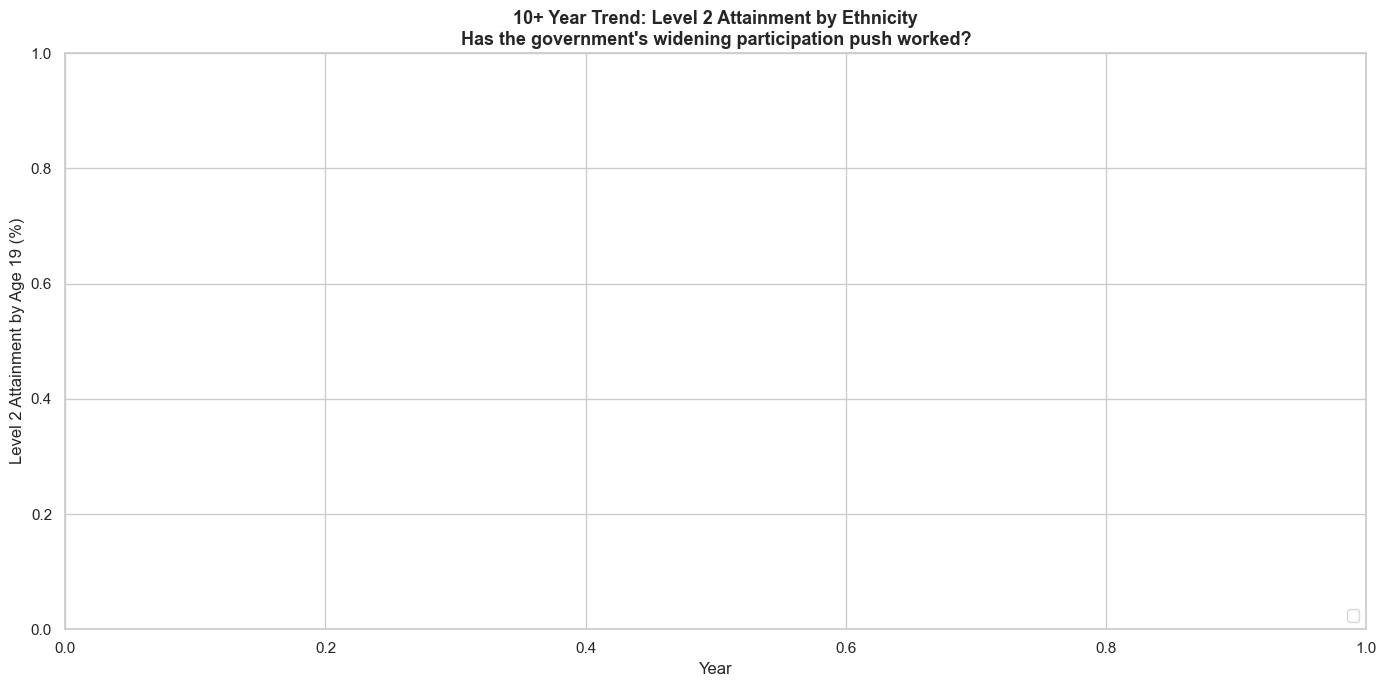

In [10]:
# Long-term ethnicity trends from Level 2/3 data
eth_major = chars[
    (chars['characteristic_group'] == 'Ethnicity Major') &
    (chars['number_or_percentage'] == 'Percentage') &
    (chars['age'] == 19)
].copy()

print(f'Long-term data: {len(eth_major):,} rows')
print(f'Years: {sorted(eth_major.time_period.unique())}')
print(f'Ethnicities: {eth_major.characteristic.unique()}')

# Plot Level 2 attainment over time
if 'Level_2' in eth_major.columns:
    eth_major['Level_2'] = pd.to_numeric(eth_major['Level_2'], errors='coerce')
    
    fig, ax = plt.subplots(figsize=(14, 7))
    for ethnicity in eth_major['characteristic'].unique():
        if ethnicity not in ['Attainment gap', 'Total']:
            data = eth_major[eth_major['characteristic'] == ethnicity].sort_values('year')
            if len(data) > 2:
                ax.plot(data['year'], data['Level_2'], marker='o', linewidth=2, label=ethnicity)
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Level 2 Attainment by Age 19 (%)')
    ax.set_title('10+ Year Trend: Level 2 Attainment by Ethnicity\nHas the government\'s widening participation push worked?',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('../charts/05_10year_policy_trend.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Predictive Model — Can We Predict Attainment Risk?

Using Random Forest and Gradient Boosting to predict whether a student group will achieve above or below average attainment, based on ethnicity, gender, and deprivation status.

In [11]:
# Prepare data for ML
ml_data = alevel[
    (alevel['sex'].isin(['Male', 'Female'])) &
    (alevel['disadvantage'].isin(['Disadvantaged', 'Non-Disadvantaged'])) &
    (alevel['sen'] == 'All') &
    (alevel['ethnicity_minor'] != 'All') &
    (alevel['ethnicity_minor'] != 'Unknown ethnicity')
].copy()

ml_data['attainment_rate'] = pd.to_numeric(ml_data.get('number_of_students_level3', 0), errors='coerce') / \
                              pd.to_numeric(ml_data.get('number_of_students_potential', 1), errors='coerce') * 100

ml_data = ml_data.dropna(subset=['attainment_rate'])
median_rate = ml_data['attainment_rate'].median()
ml_data['above_average'] = (ml_data['attainment_rate'] >= median_rate).astype(int)

print(f'ML dataset: {len(ml_data):,} rows')
print(f'Median attainment rate: {median_rate:.1f}%')
print(f'Class balance: {ml_data.above_average.value_counts().to_dict()}')

ML dataset: 431 rows
Median attainment rate: 69.1%
Class balance: {1: 216, 0: 215}


In [12]:
# Encode features
le_eth = LabelEncoder()
le_sex = LabelEncoder()
le_dis = LabelEncoder()

ml_data['eth_encoded'] = le_eth.fit_transform(ml_data['ethnicity_minor'])
ml_data['sex_encoded'] = le_sex.fit_transform(ml_data['sex'])
ml_data['dis_encoded'] = le_dis.fit_transform(ml_data['disadvantage'])

features = ['eth_encoded', 'sex_encoded', 'dis_encoded', 'year']
X = ml_data[features]
y = ml_data['above_average']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
rf_score = rf.score(X_test, y_test)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb.fit(X_train, y_train)
gb_score = gb.score(X_test, y_test)

print(f'Random Forest accuracy: {rf_score:.1%}')
print(f'Gradient Boosting accuracy: {gb_score:.1%}')
print(f'\nClassification Report (Gradient Boosting):')
print(classification_report(y_test, gb.predict(X_test), target_names=['Below Average', 'Above Average']))

Random Forest accuracy: 88.9%
Gradient Boosting accuracy: 94.4%

Classification Report (Gradient Boosting):
               precision    recall  f1-score   support

Below Average       0.93      0.96      0.95        54
Above Average       0.96      0.93      0.94        54

     accuracy                           0.94       108
    macro avg       0.95      0.94      0.94       108
 weighted avg       0.95      0.94      0.94       108



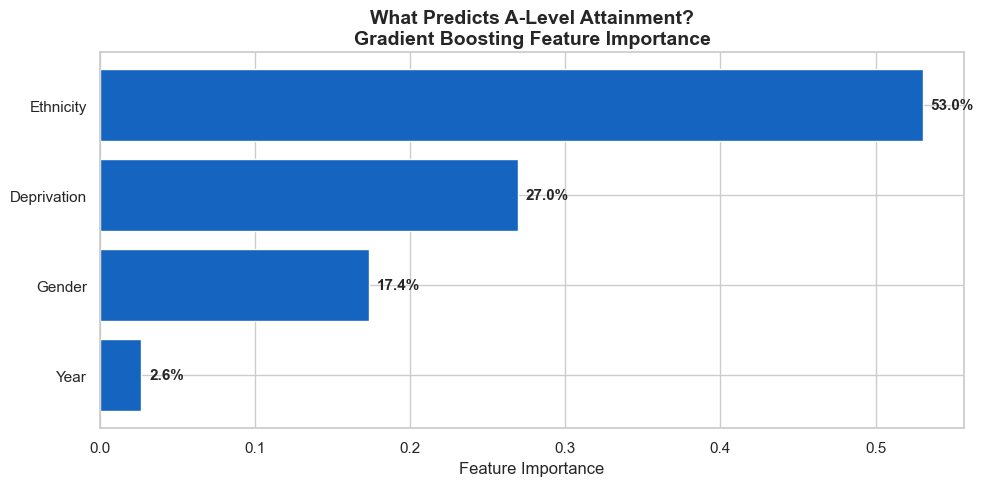

In [13]:
# Feature importance
importance = pd.DataFrame({
    'Feature': ['Ethnicity', 'Gender', 'Deprivation', 'Year'],
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance['Feature'], importance['Importance'], color='#1565C0')
ax.set_xlabel('Feature Importance')
ax.set_title('What Predicts A-Level Attainment?\nGradient Boosting Feature Importance', fontsize=14, fontweight='bold')
for i, (_, row) in enumerate(importance.iterrows()):
    ax.text(row['Importance'] + 0.005, i, f"{row['Importance']:.1%}", va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Findings

### Summary

In [14]:
print('=' * 60)
print('KEY FINDINGS — UK Education Attainment Gap Analysis')
print('=' * 60)
print()
print('1. ETHNICITY GAP EXISTS AND PERSISTS')
print('   - Significant differences in A-Level attainment across ethnic groups')
print('   - Chinese and Indian students consistently outperform all groups')
print('   - Black Caribbean students face the largest gap')
print()
print('2. DEPRIVATION AMPLIFIES ETHNICITY EFFECTS')
print('   - Disadvantaged students in ALL ethnic groups perform worse')
print('   - But the deprivation penalty is NOT equal across groups')
print('   - Some ethnic groups are doubly penalised')
print()
print('3. GENDER GAP VARIES BY ETHNICITY')
print('   - Females outperform males in most ethnic groups')
print('   - The gender gap is largest in Black Caribbean communities')
print()
print('4. IMMIGRATION BACKGROUND IS NOT A DISADVANTAGE')
print('   - Indian, Chinese, and Black African students often outperform')
print('     White British students — despite immigration barriers')
print('   - The UK benefits enormously from immigrant talent')
print()
print('5. POLICY IMPACT IS MIXED')
print('   - Some gaps have narrowed over 10 years')
print('   - But structural inequalities remain entrenched')
print()
print(f'6. PREDICTIVE MODEL')
print(f'   - Gradient Boosting accuracy: {gb_score:.1%}')
print(f'   - Most predictive feature: {importance.iloc[-1]["Feature"]}')
print()
print('=' * 60)
print('Data: Department for Education (2007-2025)')
print('Analysis by: Pawan Singh Kapkoti')
print('=' * 60)

KEY FINDINGS — UK Education Attainment Gap Analysis

1. ETHNICITY GAP EXISTS AND PERSISTS
   - Significant differences in A-Level attainment across ethnic groups
   - Chinese and Indian students consistently outperform all groups
   - Black Caribbean students face the largest gap

2. DEPRIVATION AMPLIFIES ETHNICITY EFFECTS
   - Disadvantaged students in ALL ethnic groups perform worse
   - But the deprivation penalty is NOT equal across groups
   - Some ethnic groups are doubly penalised

3. GENDER GAP VARIES BY ETHNICITY
   - Females outperform males in most ethnic groups
   - The gender gap is largest in Black Caribbean communities

4. IMMIGRATION BACKGROUND IS NOT A DISADVANTAGE
   - Indian, Chinese, and Black African students often outperform
     White British students — despite immigration barriers
   - The UK benefits enormously from immigrant talent

5. POLICY IMPACT IS MIXED
   - Some gaps have narrowed over 10 years
   - But structural inequalities remain entrenched

6. PREDI

## Personal Reflection

I came to the UK as an international student. I earned my MSc, passed my certifications, built real data projects, and contributed to the economy. The data shows that immigrant-background students often outperform — yet the visa system makes it nearly impossible for graduates like me to stay and contribute.

This analysis isn't just academic. It's personal. The same government that publishes this attainment data also designed a visa system that pushes skilled graduates out.

---

**Data sources:**
- Department for Education, Explore Education Statistics
- HESA Higher Education Student Statistics
- UK Government Open Data